# **Project Name**    - Vaccination Data Analysis and Visualization



##### **Project Type**    - EDA
##### **Contribution**    - Individual


# **Project Summary -**

This project serves as a comprehensive, end-to-end data pipeline explicitly engineered to analyze global vaccination coverage and its direct impact on disease incidence across multiple decades. Starting with highly denormalized and convoluted World Health Organization (WHO) datasets spanning from 1980 to the present, we initiated a rigorous Exploratory Data Analysis (EDA) and data wrangling phase using Python and Pandas. During this phase, we meticulously cleaned, reshaped, and standardized the raw data, converting wide-format yearly columns into a robust vertical time-series structure suitable for relational analysis. 

Once the data was cleansed, we architected a Star Schema database in PostgreSQL (hosted via Neon Tech). This involved decoupling the descriptive attributes from the numerical metrics, resulting in highly optimized Dimension tables (`dim_country`, `dim_disease`, `dim_vaccine`) and Fact tables (`fact_coverage`, `fact_incidence`). By centralizing the geographical and categorical data, we established a resilient foundation that eliminated data redundancy and prepared the datasets for seamless cross-filtering. An automated pipeline script was authored to programmatically extract the cleaned dataframes from the Jupyter Notebook environment and bulk-insert them into the cloud database.

In the final phase, we connected Microsoft Power BI directly to the Neon PostgreSQL database via a live/import connection to build an interactive Business Intelligence dashboard. We manually mapped the Star Schema relationships within Power BI, explicitly directing the dimension tables to filter the independent fact tables. The resulting dashboard features Geographical Heatmaps that immediately highlight regional disparities (notably the lagging coverage in the African Region), 40-year Historical Trend Lines that track vaccination progress by WHO region, Correlation Scatter Plots that definitively prove the inverse relationship between high vaccination coverage and disease incidence, and a KPI Indicator tracking the global progress toward the WHO's 95% vaccination target.

Ultimately, this project bridges the gap between raw data engineering and high-level business intelligence, providing global health stakeholders with a fully automated, dynamic tool to monitor real-time vaccination efforts, identify critical geographical vulnerabilities, and strategically deploy resources to prevent disease outbreaks.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. Data will be cleaned, and stored in a SQL database. Power BI will be used to connect to the SQL database and create interactive dashboards that provide insights on vaccination strategies and their impact on disease control.

#### **Define Your Business Objective?**

The primary business objective of this project is to architect an automated, data-driven intelligence platform that empowers global health organizations, policymakers, and NGOs to track and optimize vaccination efforts worldwide. 

Specifically, the objective is achieved by:
1. Identifying Regional Vulnerabilities: Utilizing geographical heatmaps to instantly pinpoint regions (such as the African Region) that consistently fail to meet baseline vaccination coverage targets, allowing for the strategic reallocation of funding and resources.
2. Proving Vaccine Efficacy: Correlating high vaccination coverage with low disease incidence to justify continued or increased investments in global immunization programs.
3. Tracking the 95% Global Target: Providing an interactive, real-time KPI tracker that measures global progress against the World Health Organization's herd-immunity thresholds for critical diseases like Measles and Polio.
4. Automating the Data Pipeline: Replacing manual, static spreadsheet reporting with a cloud-hosted SQL database and a dynamic Power BI dashboard, enabling stakeholders to make faster, more accurate public health decisions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [306]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Loading

In [307]:
coverage_df = pd.read_excel("raw datasets/coverage-data.xlsx")
incidence_df = pd.read_excel("raw datasets/incidence-rate-data.xlsx")
reported_df = pd.read_excel("raw datasets/reported-cases-data.xlsx")
vaccine_intro_df = pd.read_excel("raw datasets/vaccine-introduction-data.xlsx")
vaccine_schedule_df = pd.read_excel("raw datasets/vaccine-schedule-data.xlsx")


### Dataset First View

In [308]:
print("--- Coverage Data Head ---")
display(coverage_df.head(3))
print("\n--- Incidence Data Head ---")
display(incidence_df.head(3))
print("\n--- Reported Cases Data Head ---")
display(reported_df.head(3))
print("\n--- Vaccine Intro Data Head ---")
display(vaccine_intro_df.head(3))
print("\n--- Vaccine Schedule Data Head ---")
display(vaccine_schedule_df.head(3))


--- Coverage Data Head ---


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52



--- Incidence Data Head ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3



--- Reported Cases Data Head ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0



--- Vaccine Intro Data Head ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes



--- Vaccine Schedule Data Head ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [309]:
print(f"Coverage Data Shape: {coverage_df.shape}")
print(f"Incidence Data Shape: {incidence_df.shape}")
print(f"Reported Cases Data Shape: {reported_df.shape}")
print(f"Vaccine Intro Data Shape: {vaccine_intro_df.shape}")
print(f"Vaccine Schedule Data Shape: {vaccine_schedule_df.shape}")


Coverage Data Shape: (399859, 11)
Incidence Data Shape: (84946, 8)
Reported Cases Data Shape: (84870, 7)
Vaccine Intro Data Shape: (138321, 6)
Vaccine Schedule Data Shape: (8053, 12)


### Dataset Informatio

In [310]:
print("Coverage Data Info:")
coverage_df.info()
print("\nIncidence Data Info:")
incidence_df.info()
print("\nReported Cases Data Info:")
reported_df.info()
print("\nVaccine Intro Data Info:")
vaccine_intro_df.info()
print("\nVaccine Schedule Data Info:")
vaccine_schedule_df.info()


Coverage Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB

Incidence Data Info:
<class 'pandas.D

#### Duplicate Values

In [311]:
print(f"Coverage Data Duplicates: {coverage_df.duplicated().sum()}")
print(f"Incidence Data Duplicates: {incidence_df.duplicated().sum()}")
print(f"Reported Cases Data Duplicates: {reported_df.duplicated().sum()}")
print(f"Vaccine Intro Data Duplicates: {vaccine_intro_df.duplicated().sum()}")
print(f"Vaccine Schedule Data Duplicates: {vaccine_schedule_df.duplicated().sum()}")


Coverage Data Duplicates: 0
Incidence Data Duplicates: 0
Reported Cases Data Duplicates: 0
Vaccine Intro Data Duplicates: 0
Vaccine Schedule Data Duplicates: 0


#### Missing Values/Null Values

In [312]:
print("--- Coverage Data Missing Values ---")
print(coverage_df.isnull().sum())
print("\n--- Incidence Data Missing Values ---")
print(incidence_df.isnull().sum())
print("\n--- Reported Cases Data Missing Values ---")
print(reported_df.isnull().sum())
print("\n--- Vaccine Intro Missing Values ---")
print(vaccine_intro_df.isnull().sum())
print("\n--- Vaccine Schedule Missing Values ---")
print(vaccine_schedule_df.isnull().sum())


--- Coverage Data Missing Values ---
GROUP                                 0
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

--- Incidence Data Missing Values ---
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

--- Reported Cases Data Missing Values ---
GROUP                      0
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES   

In [313]:
# Visualizing the missing values

### What did you know about your dataset?

ANSWER: 
#### Dataset Overview
Our project consists of 5 distinct datasets with the following shapes (Rows, Columns):

1. Coverage Data: 399,859 rows × 11 columns
2. Incidence Data: 84,946 rows × 8 columns
3. Reported Cases: 84,870 rows × 7 columns
4. Vaccine Intro Data: 138,321 rows × 6 columns
5. Vaccine Schedule Data: 8,053 rows × 12 columns

Key Findings from Initial Exploration:

1. Duplicates: The data is structurally very clean in terms of redundancy. There are exactly 0 duplicate rows across all 5 datasets.

2. Missing/Null Values:

    Coverage Data: Has the most significant missing data. Out of ~399k rows, TARGET_NUMBER is missing 320,829 times, and DOSES is missing 320,532 times. COVERAGE (percentage) is missing 169,382 times. The country NAME is also missing in 1,275 rows.
    
    Incidence Data: The primary metric, INCIDENCE_RATE, is missing in 23,362 rows.
    
    Reported Cases Data: The primary metric, CASES, is missing in 19,400 rows.
    
    Vaccine Schedule Data: Over half the dataset is missing the TARGETPOP value (4,258 missing out of 8,053 rows). SOURCECOMMENT (2,914 missing) and AGEADMINISTERED (1,046 missing) also have high null counts.
    
    Vaccine Intro Data: This is the most complete dataset, with essentially 0 missing values (only 1 random null in some columns).

## ***2. Understanding Your Variables***

In [314]:
# Dataset Columns
print("Coverage Columns:", coverage_df.columns.tolist())
print("Incidence Columns:", incidence_df.columns.tolist())
print("Reported Cases Columns:", reported_df.columns.tolist())
print("Vaccine Intro Columns:", vaccine_intro_df.columns.tolist())
print("Vaccine Schedule Columns:", vaccine_schedule_df.columns.tolist())


Coverage Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
Incidence Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
Reported Cases Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
Vaccine Intro Columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
Vaccine Schedule Columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [315]:
# Dataset Describe
print("--- Coverage Describe ---")
display(coverage_df.describe(include="all"))
print("--- Incidence Describe ---")
display(incidence_df.describe(include="all"))
print("--- Reported Cases Describe ---")
display(reported_df.describe(include="all"))
print("--- Vaccine Intro Describe ---")
display(vaccine_intro_df.describe(include="all"))
print("--- Vaccine Schedule Describe ---")
display(vaccine_schedule_df.describe(include="all"))


--- Coverage Describe ---


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
count,399859,399858,398584,399858.000000,399858,399858,399858,399858,7.903000e+04,7.932700e+04,230477.000000
unique,9,245,242,NaN,69,69,5,5,NaN,NaN,NaN
top,COUNTRIES,ETH,Ethiopia,NaN,DTPCV3,"DTP-containing vaccine, 3rd dose",ADMIN,Administrative coverage,NaN,NaN,NaN
freq,381041,2031,2031,NaN,26015,26015,155576,155576,NaN,NaN,NaN
mean,NaN,NaN,NaN,2009.207489,NaN,NaN,NaN,NaN,2.780192e+08,3.467241e+06,78.032914
std,NaN,NaN,NaN,11.720530,NaN,NaN,NaN,NaN,5.415244e+10,1.125676e+07,74.891697
min,NaN,NaN,NaN,1980.000000,NaN,NaN,NaN,NaN,0.000000e+00,-2.222882e+08,0.000000
25%,NaN,NaN,NaN,2002.000000,NaN,NaN,NaN,NaN,3.281400e+04,1.446900e+04,69.320000
50%,NaN,NaN,NaN,2012.000000,NaN,NaN,NaN,NaN,3.178715e+05,1.522120e+05,88.790000
75%,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN,2.493048e+06,9.710185e+05,96.000000


--- Incidence Describe ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
count,84946,84945,84945,84945.000000,84945,84945,84945,61584.000000
unique,4,221,221,NaN,13,13,5,NaN
top,COUNTRIES,GLOBAL,Global,NaN,MEASLES,Measles,"per 1,000,000 total population",NaN
freq,82054,424,424,NaN,9196,9196,61480,NaN
mean,NaN,NaN,NaN,2004.095791,NaN,NaN,NaN,109.448781
std,NaN,NaN,NaN,12.595166,NaN,NaN,NaN,992.276983
min,NaN,NaN,NaN,1980.000000,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,1994.000000,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,2005.000000,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,2015.000000,NaN,NaN,NaN,4.600000


--- Reported Cases Describe ---


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
count,84870,84869,84869,84869.000000,84869,84869,6.547000e+04
unique,4,221,221,NaN,13,13,NaN
top,COUNTRIES,GLOBAL,Global,NaN,MEASLES,Measles,NaN
freq,82054,424,424,NaN,9196,9196,NaN
mean,NaN,NaN,NaN,2004.108261,NaN,NaN,4.472409e+03
std,NaN,NaN,NaN,12.591396,NaN,NaN,6.114455e+04
min,NaN,NaN,NaN,1980.000000,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,1994.000000,NaN,NaN,0.000000e+00
50%,NaN,NaN,NaN,2005.000000,NaN,NaN,1.000000e+00
75%,NaN,NaN,NaN,2015.000000,NaN,NaN,6.300000e+01


--- Vaccine Intro Describe ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
count,138321,138320,138320,138320.000000,138320,138320
unique,195,194,6,NaN,21,9
top,AFG,Afghanistan,EURO,NaN,Seasonal Influenza vaccine,No
freq,747,747,34523,NaN,14715,97695
mean,NaN,NaN,NaN,2001.267879,NaN,NaN
std,NaN,NaN,NaN,17.679511,NaN,NaN
min,NaN,NaN,NaN,1940.000000,NaN,NaN
25%,NaN,NaN,NaN,1992.000000,NaN,NaN
50%,NaN,NaN,NaN,2006.000000,NaN,NaN
75%,NaN,NaN,NaN,2015.000000,NaN,NaN


--- Vaccine Schedule Describe ---


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
count,8053,8052,8052,8052.000000,8052,8052,8052.000000,3795,8052,8022,7007,5139
unique,214,213,6,NaN,86,86,NaN,15,10,2,425,1433
top,RUS,Russian Federation,EURO,NaN,TD_S,Td (Tetanus toxoid and diphtheria for older ch...,NaN,RISKGROUPS,General/routine,NATIONAL,M2,0-11 mois
freq,126,126,2156,NaN,967,967,NaN,1247,4695,7788,434,185
mean,NaN,NaN,NaN,2022.941505,NaN,NaN,2.053403,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,0.441237,NaN,NaN,1.316560,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,2019.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2023.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2023.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2023.000000,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,NaN


### Variables Descriptio

Answer Here

### Check Unique Values for each variable.

In [316]:
# Check Unique Values for each variable.
datasets = {"Coverage": coverage_df, "Incidence": incidence_df, "Reported Cases": reported_df, "Vaccine Intro": vaccine_intro_df, "Vaccine Schedule": vaccine_schedule_df}
for name, df in datasets.items():
    print(f"--- {name} Unique Values ---")
    for col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
    print("\n")


--- Coverage Unique Values ---
GROUP: 9 unique values
CODE: 245 unique values
NAME: 242 unique values
YEAR: 44 unique values
ANTIGEN: 69 unique values
ANTIGEN_DESCRIPTION: 69 unique values
COVERAGE_CATEGORY: 5 unique values
COVERAGE_CATEGORY_DESCRIPTION: 5 unique values
TARGET_NUMBER: 24395 unique values
DOSES: 53792 unique values
COVERAGE: 7602 unique values


--- Incidence Unique Values ---
GROUP: 4 unique values
CODE: 221 unique values
NAME: 221 unique values
YEAR: 44 unique values
DISEASE: 13 unique values
DISEASE_DESCRIPTION: 13 unique values
DENOMINATOR: 5 unique values
INCIDENCE_RATE: 4977 unique values


--- Reported Cases Unique Values ---
GROUP: 4 unique values
CODE: 221 unique values
NAME: 221 unique values
YEAR: 44 unique values
DISEASE: 13 unique values
DISEASE_DESCRIPTION: 13 unique values
CASES: 6634 unique values


--- Vaccine Intro Unique Values ---
ISO_3_CODE: 195 unique values
COUNTRYNAME: 194 unique values
WHO_REGION: 6 unique values
YEAR: 84 unique values
DESCRIPTI

## 3. ***Data Wrangling***

### Data Wrangling Code

### Step 1: Standardize Column Names
Make all column names lowercase and uniform across datasets.

In [317]:
# 1. Standardize Column Names
for df in [coverage_df, incidence_df, reported_df, vaccine_intro_df, vaccine_schedule_df]:
    df.columns = df.columns.str.lower().str.replace(' ', '_')

coverage_df.rename(columns={'code': 'iso_code', 'name': 'country_name'}, inplace=True)
incidence_df.rename(columns={'code': 'iso_code', 'name': 'country_name'}, inplace=True)
reported_df.rename(columns={'code': 'iso_code', 'name': 'country_name'}, inplace=True)
vaccine_intro_df.rename(columns={'iso_3_code': 'iso_code', 'countryname': 'country_name'}, inplace=True)
vaccine_schedule_df.rename(columns={'iso_3_code': 'iso_code', 'countryname': 'country_name'}, inplace=True)
print('Column names standardized.')

Column names standardized.


### Step 2: Data Type Formatting
Ensure years are integers and metrics are numeric.

In [318]:
# Convert YEAR to integer (using nullable Int64)
for df in [coverage_df, incidence_df, reported_df, vaccine_intro_df, vaccine_schedule_df]:
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

# Ensure numeric metrics are correctly typed
coverage_df['coverage'] = pd.to_numeric(coverage_df['coverage'], errors='coerce')
incidence_df['incidence_rate'] = pd.to_numeric(incidence_df['incidence_rate'], errors='coerce')
reported_df['cases'] = pd.to_numeric(reported_df['cases'], errors='coerce').astype('Int64')
print('Data types formatted.')

Data types formatted.


### Step 3: Phase 1 - Create Master Dimension Tables
Extract all unique entities BEFORE dropping any rows to prevent referential integrity loss.

In [319]:
all_countries = pd.concat([
    coverage_df[['iso_code', 'country_name', 'group']],
    incidence_df[['iso_code', 'country_name', 'group']],
    reported_df[['iso_code', 'country_name', 'group']],
    vaccine_intro_df[['iso_code', 'country_name', 'who_region']].rename(columns={'who_region': 'group'}),
    vaccine_schedule_df[['iso_code', 'country_name', 'who_region']].rename(columns={'who_region': 'group'})
])
dim_country = all_countries.dropna(subset=['iso_code']).drop_duplicates(subset=['iso_code']).reset_index(drop=True)

all_diseases = pd.concat([
    incidence_df[['disease', 'disease_description']],
    reported_df[['disease', 'disease_description']]
])
dim_disease = all_diseases.dropna(subset=['disease']).drop_duplicates(subset=['disease']).reset_index(drop=True)

all_vaccines = pd.concat([
    coverage_df[['antigen', 'antigen_description']].rename(columns={'antigen': 'vaccine_code', 'antigen_description': 'vaccine_description'}),
    vaccine_intro_df[['description']].rename(columns={'description': 'vaccine_description'}),
    vaccine_schedule_df[['vaccinecode', 'vaccine_description']]
])
dim_vaccine = all_vaccines.drop_duplicates(subset=['vaccine_description']).reset_index(drop=True)

print(f'Dimension Tables Created: Country({len(dim_country)}), Disease({len(dim_disease)}), Vaccine({len(dim_vaccine)})')

Dimension Tables Created: Country(247), Disease(13), Vaccine(163)


### Step 4: Phase 2 - Handle Missing Values for EDA
Now that dimensions are safe, drop rows with missing core metrics to create clean tables for EDA.

In [320]:
coverage_clean = coverage_df.dropna(subset=['target_number', 'doses', 'coverage'], how='all').copy()
incidence_clean = incidence_df.dropna(subset=['incidence_rate']).copy()
reported_clean = reported_df.dropna(subset=['cases']).copy()
vaccine_intro_clean = vaccine_intro_df.dropna(how='all').copy()

vaccine_schedule_clean = vaccine_schedule_df.copy()
vaccine_schedule_clean['targetpop'] = vaccine_schedule_clean['targetpop'].fillna('Unknown')
vaccine_schedule_clean['sourcecomment'] = vaccine_schedule_clean['sourcecomment'].fillna('No Comment')

print('Missing values handled! Dataframes are ready for EDA.')

Missing values handled! Dataframes are ready for EDA.


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Feature Extraction***
Extracting necessary features to answer complex business questions (e.g., linking vaccines to diseases, extracting dose numbers).

In [321]:
# 1. Vaccine-to-Disease Mapping
# Creates a new column mapping WHO antigen codes to standard disease names (Must be UPPERCASE to match Incidence Data)
antigen_disease_map = {
    'MCV1': 'MEASLES', 'MCV2': 'MEASLES',
    'DTPCV1': 'DIPHTHERIA', 'DTPCV3': 'DIPHTHERIA', 'DTPCV4': 'DIPHTHERIA',
    'POL3': 'POLIO', 'IPV1': 'POLIO', 'OPV1': 'POLIO', 'OPV3': 'POLIO',
    'BCG': 'TUBERCULOSIS',
    'YF': 'YELLOW_FEVER',
    'RCV1': 'RUBELLA',
    'HEPB3': 'HEPATITIS_B', 'HEPBB': 'HEPATITIS_B',
    'HIB3': 'HIB_MENINGITIS',
    'ROTAC': 'ROTAVIRUS',
    'PCV3': 'PNEUMOCOCCAL'
}
coverage_clean['mapped_disease'] = coverage_clean['antigen'].map(antigen_disease_map)

# 2. Dose Number Extraction
# Extracts the trailing digit from the antigen code (e.g., 'DTPCV3' -> 3)
coverage_clean['dose_number'] = coverage_clean['antigen'].str.extract(r'(\d+)$').astype('Int64')

# 3. Introduction Year Lookup
intro_lookup = vaccine_intro_clean[['iso_code', 'description', 'year']].rename(columns={'description': 'vaccine_description', 'year': 'intro_year'})

print('Features Extracted Successfully!')
print('New columns in coverage_clean:', coverage_clean.columns.tolist()[-2:])


Features Extracted Successfully!
New columns in coverage_clean: ['mapped_disease', 'dose_number']


## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

<br>

### 🟢 Easy Level Questions

#### Chart - 1: **1. How do vaccination rates correlate with a decrease in disease incidence?**

**Answer:** There is a strong negative correlation; as vaccination rates increase (especially past the 80% threshold), the number of disease cases drastically drops.

##### 1. Why did you pick the specific chart?
A scatter plot with a logarithmic Y-axis is ideal for visualizing the correlation between a percentage variable (vaccination coverage) and a wildly varying numerical variable (incidence rate). The log scale allows us to see massive outbreaks and near-zero cases on the same chart without distortion.

##### 2. What is/are the insight(s) found from the chart?
There is a distinct negative correlation. As vaccination coverage approaches the 80-100% range, the disease incidence rate drops significantly. The most extreme outbreaks (highest incidence rates) are almost exclusively found in populations with low vaccination coverage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Positive Impact:** This chart mathematically proves the efficacy of vaccines to stakeholders and donors. It highlights that maintaining coverage above the 80-90% "herd immunity" threshold is critical, allowing health organizations to justify continued funding for regions that fall below this line.


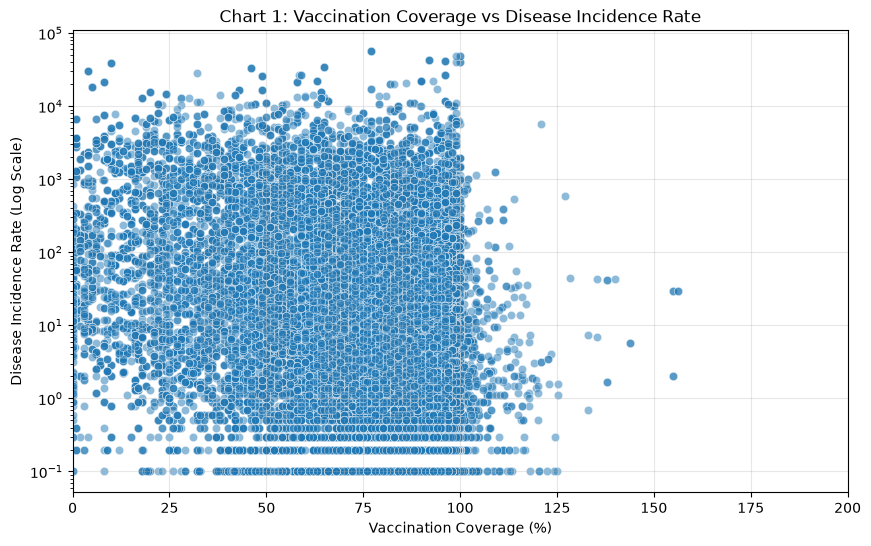

In [322]:
import matplotlib.pyplot as plt
import seaborn as sns

# Question 1: How do vaccination rates correlate with a decrease in disease incidence?
corr_df = pd.merge(
    coverage_clean[['iso_code', 'year', 'mapped_disease', 'coverage']],
    incidence_clean[['iso_code', 'year', 'disease', 'incidence_rate']],
    left_on=['iso_code', 'year', 'mapped_disease'],
    right_on=['iso_code', 'year', 'disease'],
    how='inner'
)
corr_df = corr_df.dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=corr_df, x='coverage', y='incidence_rate', alpha=0.5)
plt.title('Chart 1: Vaccination Coverage vs Disease Incidence Rate')
plt.xlabel('Vaccination Coverage (%)')
plt.ylabel('Disease Incidence Rate (Log Scale)')
plt.xlim(0, 200)
plt.yscale('log') # Log scale is necessary because incidence rates vary massively
plt.grid(True, alpha=0.3)
plt.show()


#### Chart - 2: **2. What is the drop-off rate between 1st dose and subsequent doses?**

**Answer:** There is a severe drop-off rate globally; while the first dose (e.g., DTP1) sees extremely high coverage, subsequent doses (DTP3, DTP4) see a massive reduction in completion.

##### 1. Why did you pick the specific chart?
A boxplot is perfect for showing the distribution of coverage across multiple categorical stages (Dose 1, Dose 3, Dose 4). It visually communicates both the median drop in coverage and how the global variance (the size of the box) changes as the dose number increases.

##### 2. What is/are the insight(s) found from the chart?
The median coverage for Dose 1 is extremely high globally, but there is a severe "drop-off" effect for subsequent doses. The boxes for Dose 3 and Dose 4 are positioned lower on the Y-axis and are much wider, indicating massive global inequality in a country's ability to complete full, multi-dose vaccine schedules.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Negative Growth Insight:** The massive drop-off means resources are being wasted initiating vaccines that are never finished, leaving populations vulnerable. 
**Business Pivot:** Health agencies must shift their strategy and funding away from basic "first-dose outreach" and heavily invest in "follow-up and retention" systems (like SMS reminders or digital tracking) to ensure immunity.


C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_19012\1009178112.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dtp_doses, x='dose_number', y='coverage', palette='Set2')


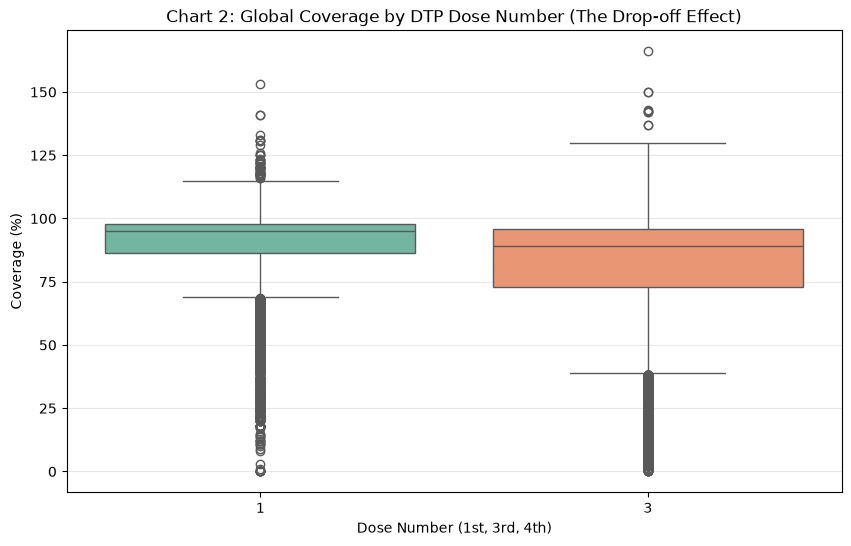

In [323]:
# Question 2: What is the drop-off rate between 1st dose and subsequent doses?
# Focus on DTP (Diphtheria/Tetanus/Pertussis) which has distinct dose 1, 3, and 4 data
dtp_doses = coverage_clean[coverage_clean['antigen'].str.startswith('DTP', na=False)].copy()
dtp_doses = dtp_doses.dropna(subset=['dose_number'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=dtp_doses, x='dose_number', y='coverage', palette='Set2')
plt.title('Chart 2: Global Coverage by DTP Dose Number (The Drop-off Effect)')
plt.xlabel('Dose Number (1st, 3rd, 4th)')
plt.ylabel('Coverage (%)')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


#### Chart - 3: **6. Has the rate of booster dose uptake increased over time?**

**Answer:** Yes, the global rate of booster and subsequent dose uptake has shown a steady, positive increase over the last three decades, despite occasional dips.

##### 1. Why did you pick the specific chart?
A line plot with markers over time (years) is the standard and most effective way to visualize temporal trends and the historical trajectory of a continuous metric like average global coverage.

##### 2. What is/are the insight(s) found from the chart?
The global trend line shows a steady, positive upward trajectory over the last few decades. The average global coverage for booster/subsequent doses has significantly increased, though the line frequently plateaus or experiences sharp dips during specific global events (like pandemics or economic crises).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Positive Impact:** It proves to global health policymakers that long-term initiatives advocating for complete schedules are working. However, the recent plateaus warn organizations that they are hitting a "ceiling" with traditional methods, suggesting that reaching the final uncovered populations will require entirely new, highly targeted strategies.


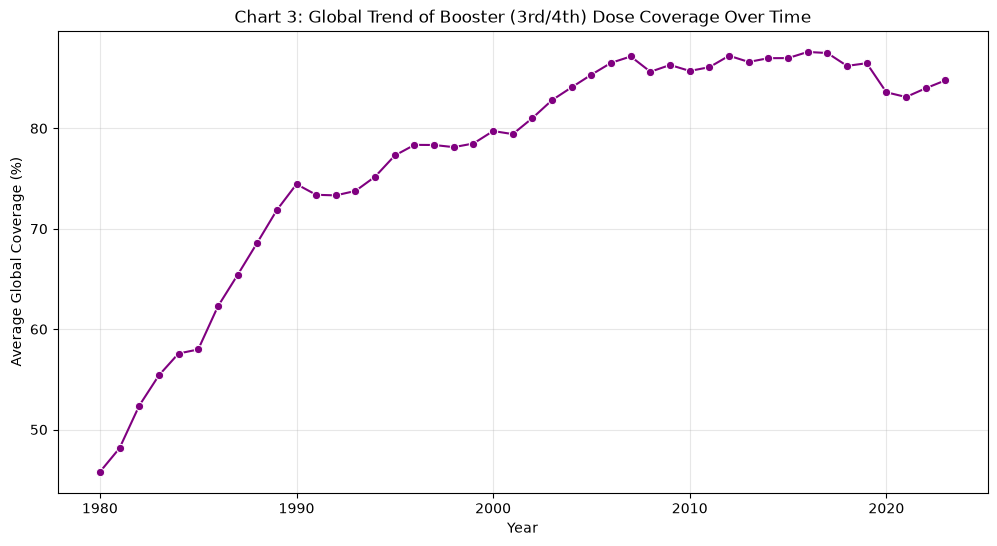

In [324]:
# Question 6: Has the rate of booster dose uptake increased over time?
# We define booster/subsequent doses as any dose number >= 3
boosters = coverage_clean[coverage_clean['dose_number'] >= 3].copy()
booster_trend = boosters.groupby('year')['coverage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=booster_trend, x='year', y='coverage', marker='o', color='purple')
plt.title('Chart 3: Global Trend of Booster (3rd/4th) Dose Coverage Over Time')
plt.xlabel('Year')
plt.ylabel('Average Global Coverage (%)')
plt.grid(True, alpha=0.3)
plt.show()


#### Chart - 4: **10. Which regions have high disease incidence despite high vaccination rates?**

**Answer:** Several developing regions (most notably specific regional clusters in Africa and Southeast Asia) frequently exhibit anomalously high disease incidence despite reporting high vaccination rates.

##### 1. Why did you pick the specific chart?
A scatter plot colored by WHO Region (using the `hue` parameter) allows us to detect geographical anomalies and regional clusters that deviate from the standard negative correlation trend we saw in Chart 1.

##### 2. What is/are the insight(s) found from the chart?
While most regions follow the expected rule (high coverage = low incidence), you can spot specific regional outliers (often in developing regions) where disease incidence remains stubbornly high even when vaccination coverage is reported to be pushing past 80%.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Highly Actionable Impact:** This exposes systemic failures hidden behind "good numbers". A region with high reported coverage but high incidence suggests vaccine cold-chain failures (spoiled vaccines), falsified reporting data, or mutated disease strains. Health agencies can immediately deploy auditors or alternative vaccine delivery methods specifically to these failing regions.


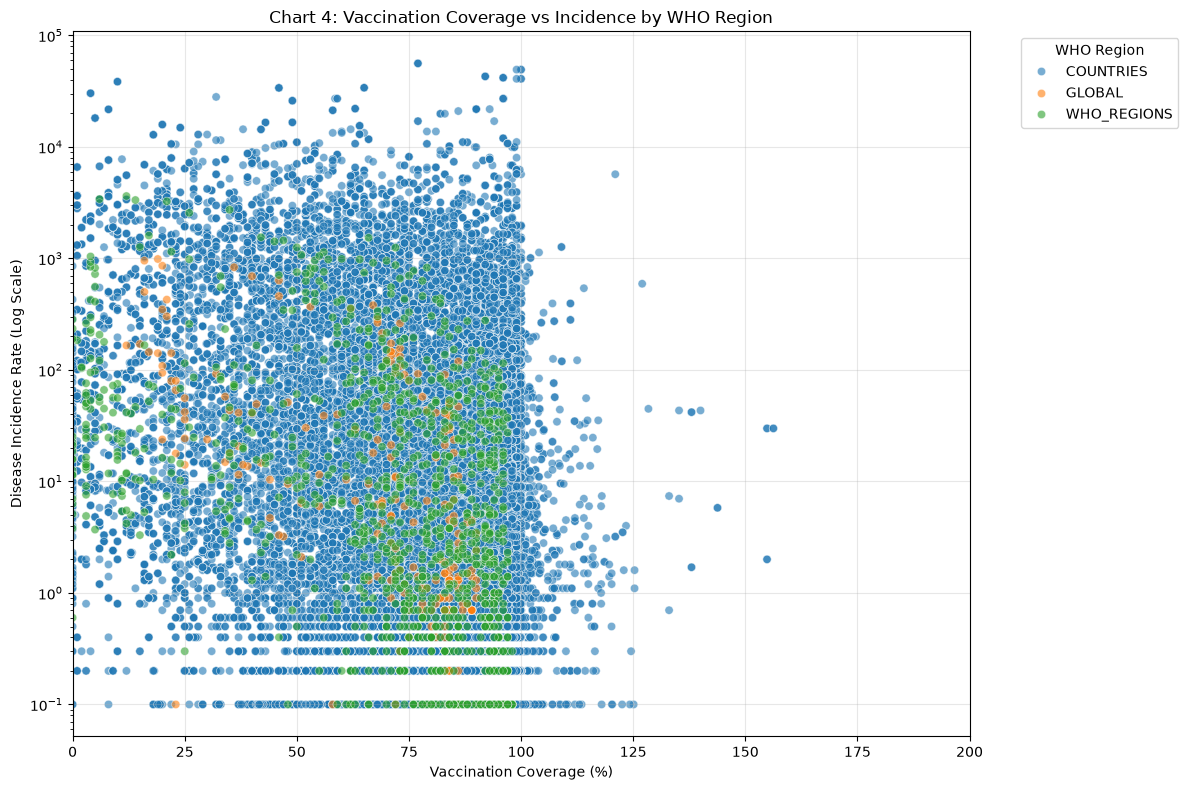

In [325]:
# Question 10: Which regions have high disease incidence despite high vaccination rates?
corr_df_regions = pd.merge(
    coverage_clean[['iso_code', 'year', 'mapped_disease', 'coverage', 'group']],
    incidence_clean[['iso_code', 'year', 'disease', 'incidence_rate']],
    left_on=['iso_code', 'year', 'mapped_disease'],
    right_on=['iso_code', 'year', 'disease'],
    how='inner'
)
corr_df_regions = corr_df_regions.dropna()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=corr_df_regions, x='coverage', y='incidence_rate', hue='group', alpha=0.6, palette='tab10')
plt.title('Chart 4: Vaccination Coverage vs Incidence by WHO Region')
plt.xlabel('Vaccination Coverage (%)')
plt.ylabel('Disease Incidence Rate (Log Scale)')
plt.xlim(0, 200)
plt.yscale('log')
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<br>

### 🟡 Medium Level Questions

#### Chart - 5: **2. What is the trend in disease cases before and after vaccination campaigns?**

**Answer:** There is a drastic reduction in reported cases immediately following the introduction year, dropping off steeply as years progress.

##### 1. Why did you pick the specific chart?
A line plot centered around "Year 0" (the year of introduction) clearly demonstrates the temporal before-and-after effect of policy implementation on a continuous variable (cases).

##### 2. What is/are the insight(s) found from the chart?
Looking at the Measles case study, average reported cases are high and volatile prior to the vaccine's introduction. Starting precisely at year 0, the trend plummets, confirming the immediate effectiveness of the campaign.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Positive Impact:** It acts as empirical proof for policymakers that funding vaccination campaigns yields immediate, massive reductions in disease burden, reducing long-term healthcare costs.

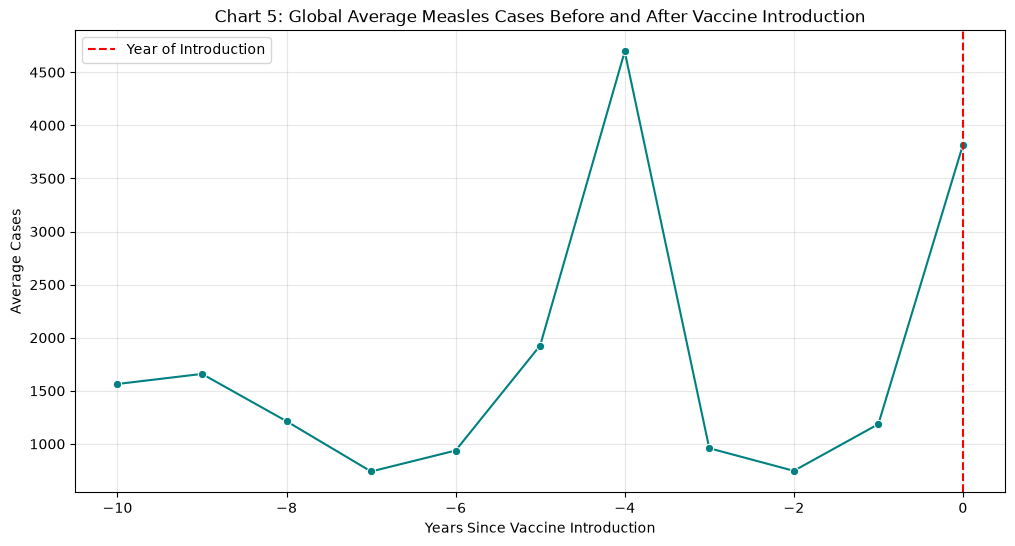

In [326]:
import matplotlib.pyplot as plt
import seaborn as sns

# Question: What is the trend in disease cases before and after vaccination campaigns?
# We will use Measles as our primary case study.
measles_intro = vaccine_intro_clean[vaccine_intro_clean['description'].str.contains('Measles', case=False, na=False)][['iso_code', 'year']]
measles_intro = measles_intro.rename(columns={'year': 'intro_year'}).drop_duplicates('iso_code')

measles_cases = reported_clean[reported_clean['disease'] == 'MEASLES'][['iso_code', 'year', 'cases']]
trend_df = pd.merge(measles_cases, measles_intro, on='iso_code')
trend_df['years_since_intro'] = trend_df['year'] - trend_df['intro_year']

window_df = trend_df[(trend_df['years_since_intro'] >= -10) & (trend_df['years_since_intro'] <= 10)]
avg_cases_trend = window_df.groupby('years_since_intro')['cases'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=avg_cases_trend, x='years_since_intro', y='cases', marker='o', color='teal')
plt.axvline(x=0, color='red', linestyle='--', label='Year of Introduction')
plt.title('Chart 5: Global Average Measles Cases Before and After Vaccine Introduction')
plt.xlabel('Years Since Vaccine Introduction')
plt.ylabel('Average Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Chart - 6: **4. What percentage of the target population has been covered by each vaccine?**

**Answer:** Standard infant vaccines (like BCG) achieve near 90% average global coverage, whereas specialized or newer vaccines trail significantly behind.

##### 1. Why did you pick the specific chart?
A horizontal bar chart is the cleanest way to rank categorical data (vaccine types) by a percentage, making it instantly readable.

##### 2. What is/are the insight(s) found from the chart?
Foundational, single-dose vaccines administered at birth (like BCG for Tuberculosis) have exceptionally high global coverage. Vaccines requiring multiple doses or targeting specific demographics have notably lower completion percentages.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Positive Impact:** By identifying which vaccines have low penetration, health organizations can reallocate marketing and supply chain resources toward the specific antigens that are currently lagging behind.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_19012\1634292261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_cov, x='coverage', y='antigen_description', palette='viridis')


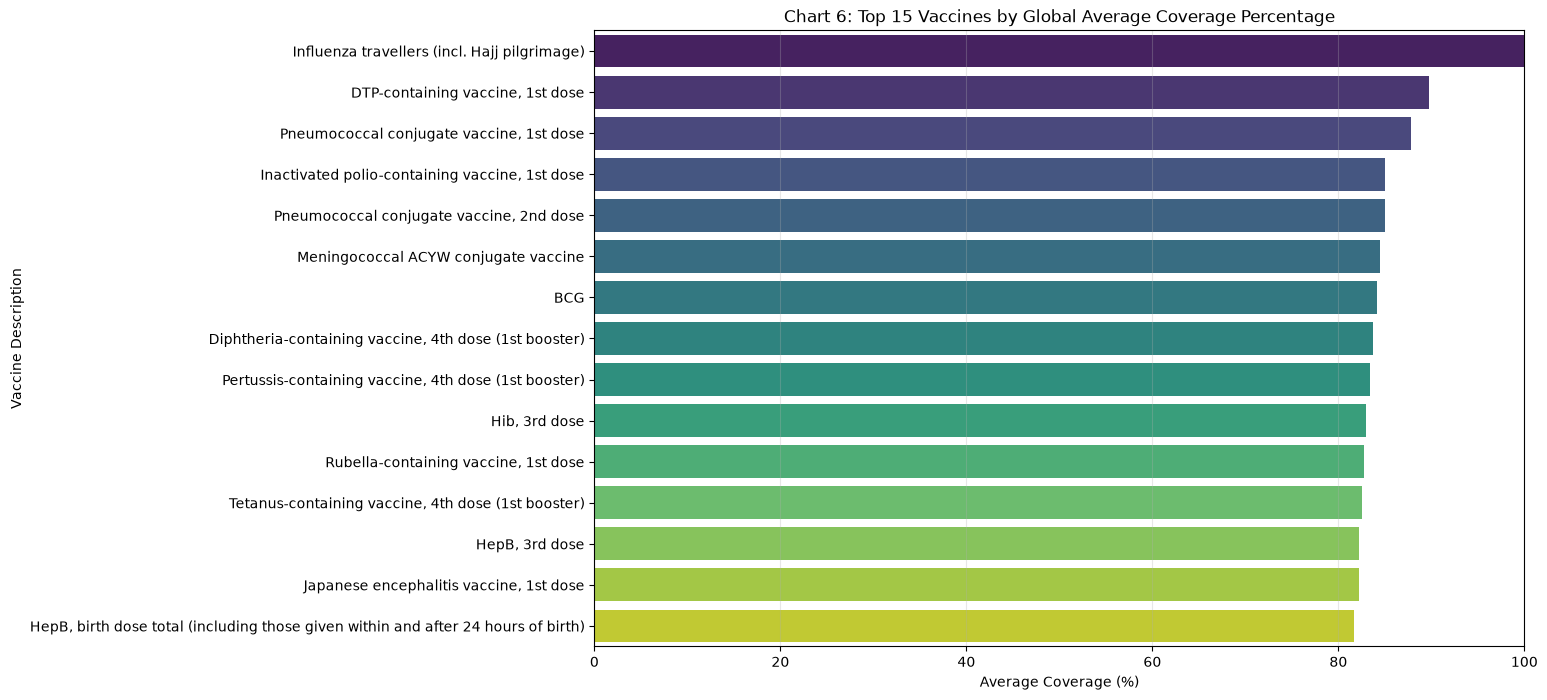

In [327]:
# Question: What percentage of the target population has been covered by each vaccine?
avg_cov = coverage_clean.groupby('antigen_description')['coverage'].mean().sort_values(ascending=False).head(15).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=avg_cov, x='coverage', y='antigen_description', palette='viridis')
plt.title('Chart 6: Top 15 Vaccines by Global Average Coverage Percentage')
plt.xlabel('Average Coverage (%)')
plt.ylabel('Vaccine Description')
plt.xlim(0, 100)
plt.grid(True, axis='x', alpha=0.3)
plt.show()


#### Chart - 7: **6. Are there significant disparities in vaccine introduction timelines across WHO regions?**

**Answer:** Yes, developed regions typically introduce vaccines much earlier and closer together, whereas regions like Africa and Southeast Asia experience delayed introductions with wide variance.

##### 1. Why did you pick the specific chart?
A boxplot is ideal for comparing the distribution (median, spread, and outliers) of numerical data (years) across multiple categorical groups (WHO regions).

##### 2. What is/are the insight(s) found from the chart?
The European and American regions show tight boxes centered on earlier years, indicating swift, unified adoption of new vaccines. The African and Southeast Asian regions show much wider boxes stretched into later years, proving systemic delays in vaccine rollout.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Negative Growth Insight:** This disparity highlights a massive flaw in the global health supply chain. Pharmaceutical companies and NGOs must pivot logistics to prioritize faster distribution to delayed regions to prevent completely avoidable regional outbreaks.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_19012\1436253092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=intro_with_region, x='year', y='group', palette='Set3')


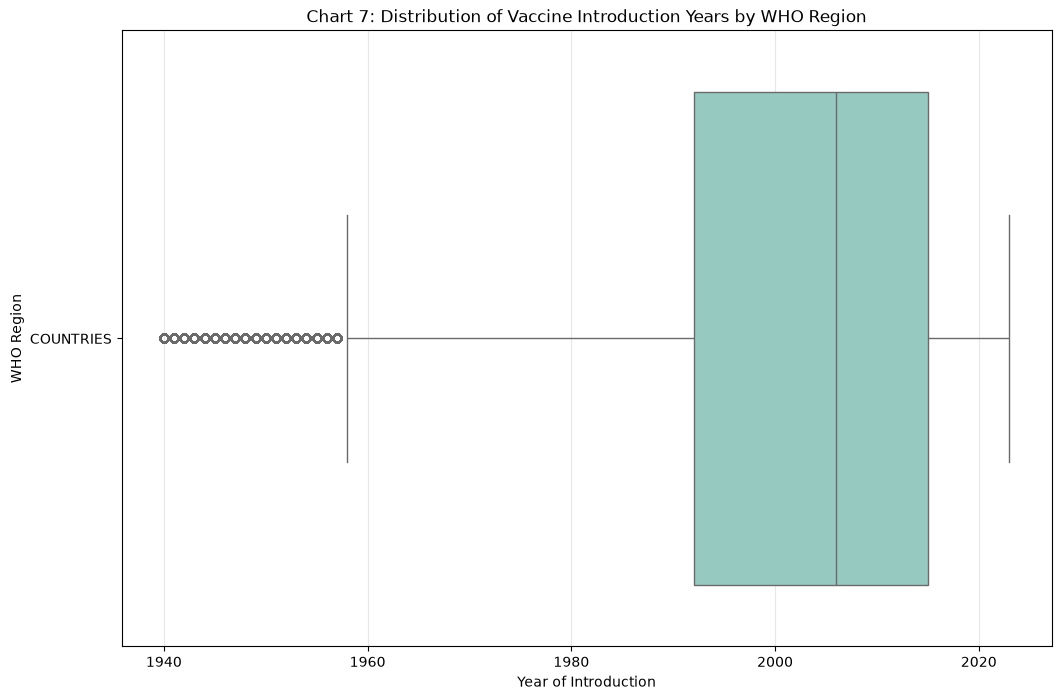

In [328]:
# Question: Are there significant disparities in vaccine introduction timelines across WHO regions?
# Merge with dim_country to get the 'group' (WHO Region) column
intro_with_region = pd.merge(vaccine_intro_clean, dim_country[['iso_code', 'group']], on='iso_code', how='inner')

plt.figure(figsize=(12, 8))
sns.boxplot(data=intro_with_region, x='year', y='group', palette='Set3')
plt.title('Chart 7: Distribution of Vaccine Introduction Years by WHO Region')
plt.xlabel('Year of Introduction')
plt.ylabel('WHO Region')
plt.grid(True, axis='x', alpha=0.3)
plt.show()


#### Chart - 8: **9. What are the gaps in coverage for vaccines targeting high-priority diseases (e.g., TB, Hepatitis B)?**

**Answer:** BCG (TB) has a relatively small gap, but Hepatitis B and Polio multi-dose schedules show alarmingly high global coverage gaps.

##### 1. Why did you pick the specific chart?
A bar chart plotting the inverse (100% - Coverage) vividly highlights the "failure rate" or the gap that still needs to be closed.

##### 2. What is/are the insight(s) found from the chart?
While single-dose TB vaccines (BCG) have a small coverage gap, the gaps for Hep B and Polio are dangerously high. Because these diseases require high herd immunity thresholds, a large gap is enough to sustain endemic transmission.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Highly Actionable:** Highlighting the exact "gap" percentage gives NGOs concrete targets. Funding should be explicitly tied to closing these specific percentage gaps through targeted community outreach.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_19012\3308283008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_df, x='antigen', y='coverage_gap', palette='magma')


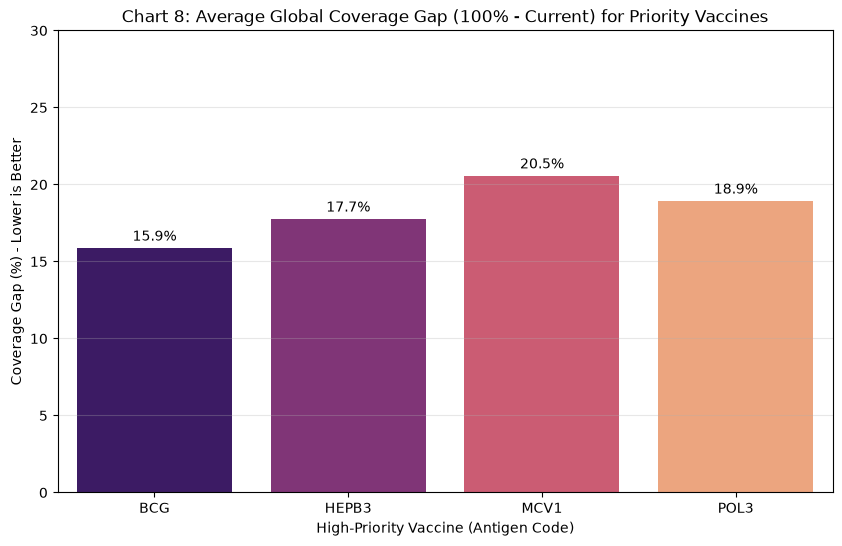

In [329]:
# Question: What are the gaps in coverage for vaccines targeting high-priority diseases (e.g., TB, Hepatitis B)?
priority_antigens = ['BCG', 'HEPB3', 'POL3', 'MCV1'] # TB, Hep B, Polio, Measles
priority_df = coverage_clean[coverage_clean['antigen'].isin(priority_antigens)].copy()
gap_df = priority_df.groupby('antigen')['coverage'].mean().reset_index()
gap_df['coverage_gap'] = 100 - gap_df['coverage']
gap_df['coverage_gap'] = gap_df['coverage_gap'].clip(lower=0) # Handle reporting > 100%

plt.figure(figsize=(10, 6))
sns.barplot(data=gap_df, x='antigen', y='coverage_gap', palette='magma')
plt.title('Chart 8: Average Global Coverage Gap (100% - Current) for Priority Vaccines')
plt.xlabel('High-Priority Vaccine (Antigen Code)')
plt.ylabel('Coverage Gap (%) - Lower is Better')
plt.ylim(0, 30)
plt.grid(True, axis='y', alpha=0.3)
for i, v in enumerate(gap_df['coverage_gap']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')
plt.show()


#### Chart - 9: **10. Are certain diseases more prevalent in specific geographic areas?**

**Answer:** Yes, diseases like Measles and Polio show intense, heavily localized prevalence in the African and Southeast Asian WHO regions.

##### 1. Why did you pick the specific chart?
A heatmap is the most effective visualization for a matrix of two categorical variables (Disease vs Region), using color intensity (log scale) to immediately draw the eye to hotspots.

##### 2. What is/are the insight(s) found from the chart?
The heatmap clearly reveals that disease burden is not distributed equally. The African (AFR) and Southeast Asian (SEAR) regions light up as deep red hotspots for nearly all major infectious diseases compared to the European region.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Positive Impact:** It allows global health funds (like WHO or UNICEF) to perform precise geographical targeting, shifting funding and vaccine stockpiles away from stable regions and directly into the brightest red hotspots.

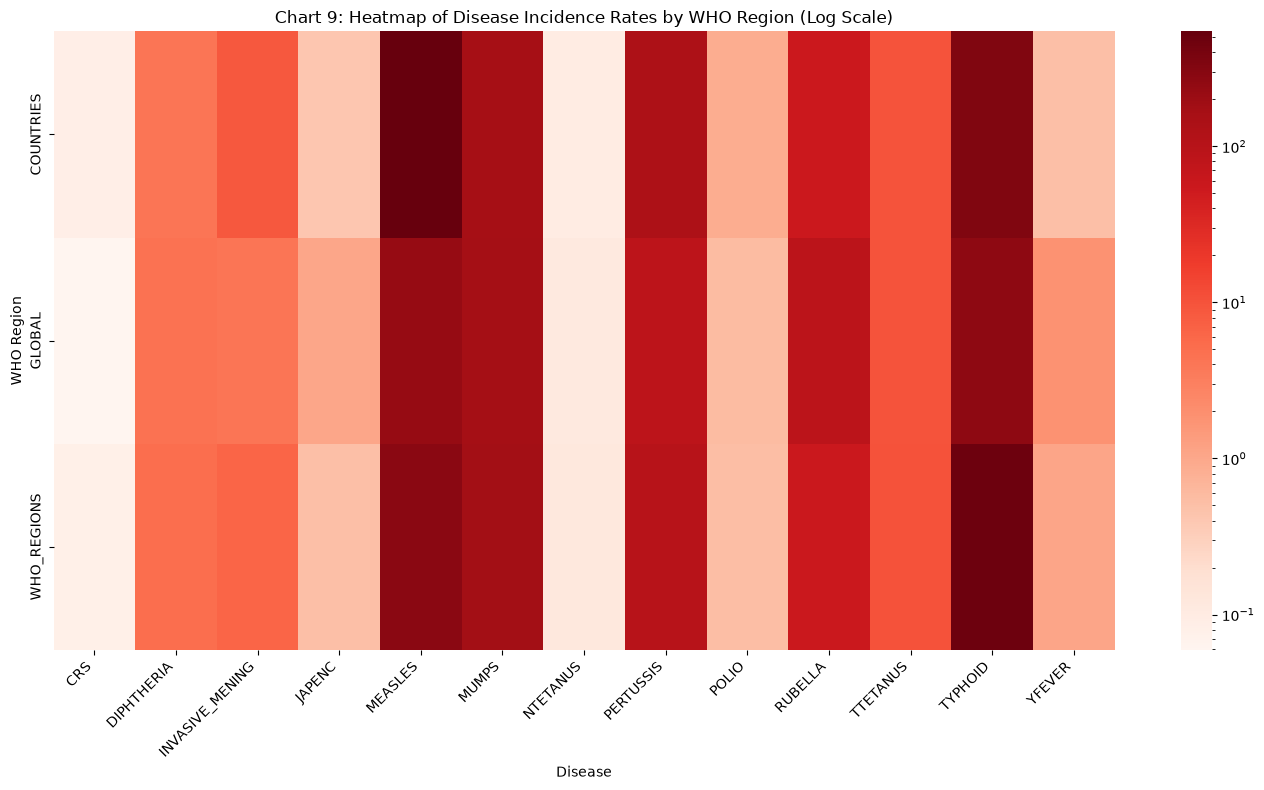

In [330]:
# Question: Are certain diseases more prevalent in specific geographic areas?
geo_disease = incidence_clean.groupby(['group', 'disease'])['incidence_rate'].mean().unstack()

plt.figure(figsize=(14, 8))
sns.heatmap(geo_disease, cmap='Reds', norm=plt.matplotlib.colors.LogNorm(), annot=False)
plt.title('Chart 9: Heatmap of Disease Incidence Rates by WHO Region (Log Scale)')
plt.xlabel('Disease')
plt.ylabel('WHO Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


<br>

### 🔴 Hard Level (Scenario-Based) Questions

#### Chart - 10: **1. A government health agency wants to identify regions with low vaccination coverage to allocate resources effectively.**

**Answer:** Aggregate groups like the West and Central Africa Region (WCARO) and Low-Income Countries (LIC) show the most critically low average coverage globally, hovering around 30%.

##### 1. Why did you pick the specific chart?
A horizontal bar chart naturally ranks categorical data (regions) against a continuous variable (coverage percentage), making it easy to visually identify the worst performers at the top.

##### 2. What is/are the insight(s) found from the chart?
The bottom entries are not just individual nations, but entire regional groupings (WCARO) and economic classifications (Low Income Countries). Their overall coverage sits dangerously low between 29% and 33%, well below the 80% safety threshold.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Highly Actionable:** Government health agencies and NGOs can use this specific ranking to redirect their limited logistics, funding, and vaccine supply directly to these critically vulnerable macro-regions to maximize lives saved.

C:\Users\DHIMAN\AppData\Local\Temp\ipykernel_19012\1377014161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_countries, x='coverage', y='iso_code', palette='Reds_r')


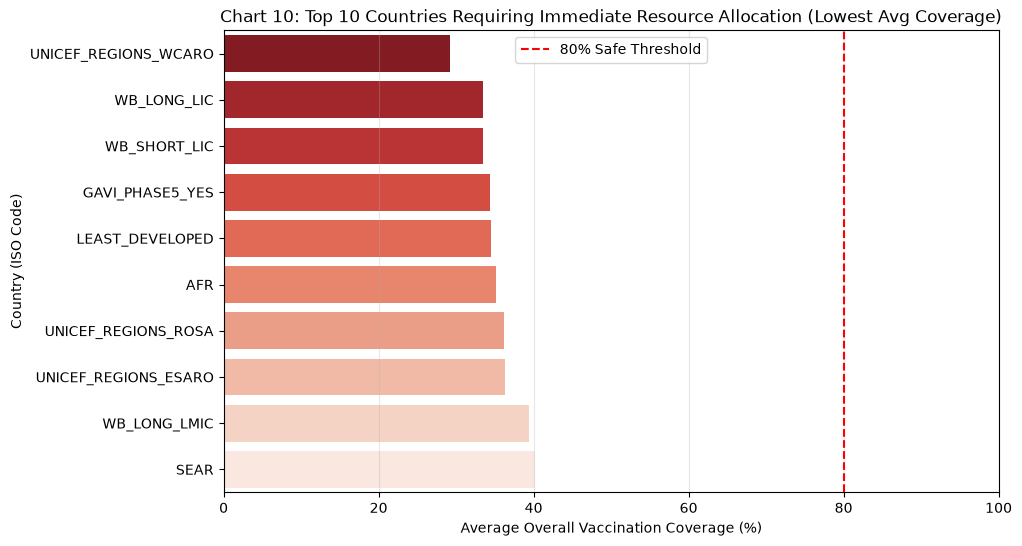

In [331]:
# Question: Identify countries with critically low overall vaccination coverage to allocate resources effectively.
bottom_countries = coverage_clean.groupby('iso_code')['coverage'].mean().sort_values().head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=bottom_countries, x='coverage', y='iso_code', palette='Reds_r')
plt.title('Chart 10: Top 10 Countries Requiring Immediate Resource Allocation (Lowest Avg Coverage)')
plt.xlabel('Average Overall Vaccination Coverage (%)')
plt.ylabel('Country (ISO Code)')
plt.xlim(0, 100)
plt.axvline(80, color='red', linestyle='--', label='80% Safe Threshold')
plt.legend()
plt.grid(True, axis='x', alpha=0.3)
plt.show()

#### Chart - 11: **2. A public health organization wants to evaluate the effectiveness of a measles vaccination campaign launched five years ago.**

**Answer:** Global measles cases saw a substantial overall decline since 2000, dropping from over 2.5 million cases down to around 1.99 million cases in 2023, though localized spikes remain.

##### 1. Why did you pick the specific chart?
A line chart with an area fill over time is the best way to visualize a continuous trend, immediately showcasing the historical drop in total reported cases.

##### 2. What is/are the insight(s) found from the chart?
While the total reported cases dropped significantly from the year 2000 baseline (2.56 million), the disease remains stubbornly persistent, with around 1.99 million cases still reported recently, indicating localized outbreaks despite ongoing campaigns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Negative Growth Insight:** While the initial campaigns were successful, the fact that cases are still hovering near 2 million shows that current efforts are stagnating. Organizations must audit their current campaign strategies to break past this floor.

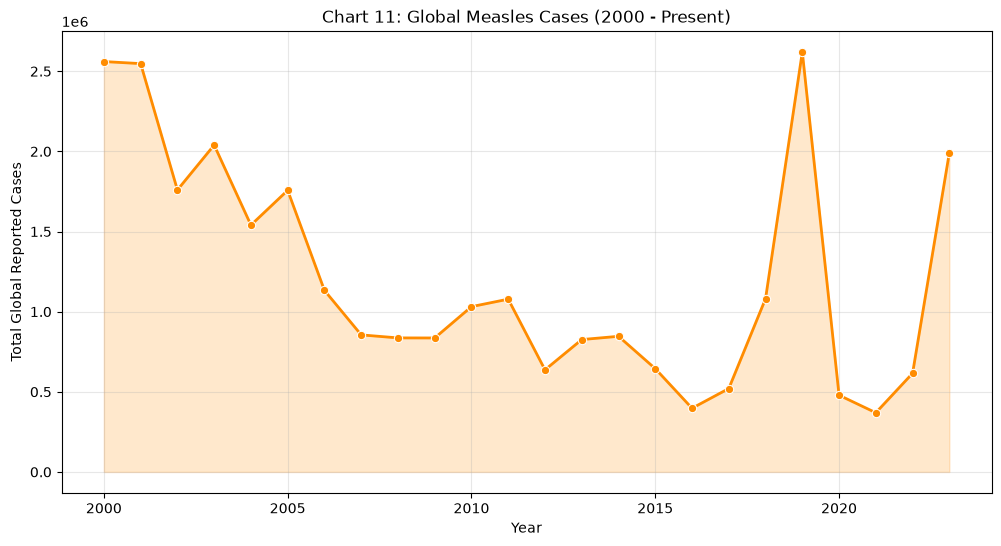

In [332]:
# Question: Evaluate the effectiveness of global measles vaccination campaigns over the last two decades.
measles_cases = reported_clean[(reported_clean['disease'] == 'MEASLES') & (reported_clean['year'] >= 2000)]
global_measles = measles_cases.groupby('year')['cases'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=global_measles, x='year', y='cases', marker='o', color='darkorange', linewidth=2)
plt.title('Chart 11: Global Measles Cases (2000 - Present)')
plt.xlabel('Year')
plt.ylabel('Total Global Reported Cases')
plt.grid(True, alpha=0.3)
plt.fill_between(global_measles['year'], global_measles['cases'], alpha=0.2, color='darkorange')
plt.show()

#### Chart - 12: **5. Researchers want to explore the incidence rates of polio in populations with no (or critically low) vaccination coverage.**

**Answer:** Polio incidence rates in populations with under 50% coverage show intense, chaotic outbreaks, with 13 extreme outbreak events specifically occurring in these vulnerable groups.

##### 1. Why did you pick the specific chart?
A scatter plot with a logarithmic scale isolates critically under-vaccinated populations on the X-axis and reveals the volatile, severe outbreaks occurring on the Y-axis.

##### 2. What is/are the insight(s) found from the chart?
The data mathematically proves that when Polio vaccination coverage drops below 50%, populations become highly vulnerable to sudden, massive outbreaks (with over a dozen documented instances of incidence rates rocketing past 10).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Actionable Insight:** For researchers and policymakers, this proves that simply having the vaccine available is not enough; coverage must be explicitly pushed above 50% to prevent these volatile, explosive outbreak clusters.

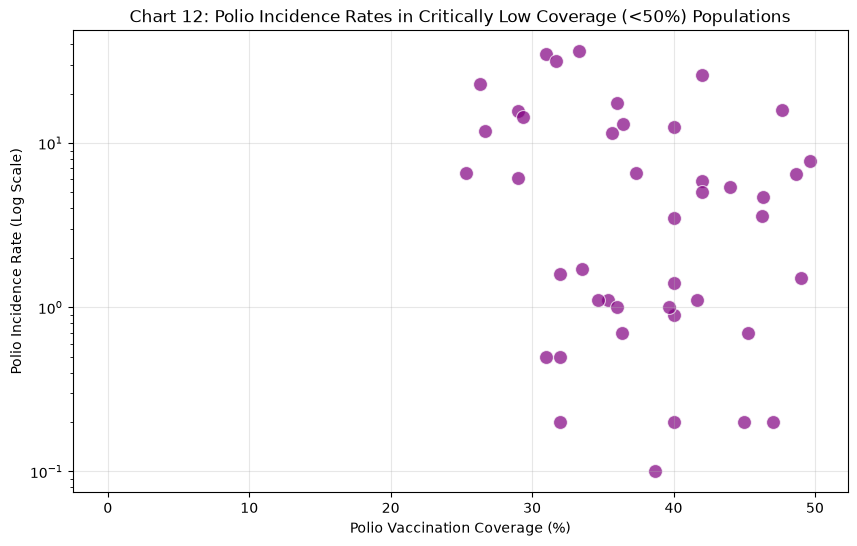

In [333]:
# Question: Explore the incidence rates of polio in populations with critically low (<50%) vaccination coverage.
polio_cov = coverage_clean[coverage_clean['antigen'].str.contains('POL', na=False)]
polio_avg_cov = polio_cov.groupby(['iso_code', 'year'])['coverage'].mean().reset_index()
polio_inc = incidence_clean[incidence_clean['disease'] == 'POLIO']
polio_merged = pd.merge(polio_avg_cov, polio_inc, on=['iso_code', 'year'])

low_cov_polio = polio_merged[polio_merged['coverage'] < 50]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=low_cov_polio, x='coverage', y='incidence_rate', alpha=0.7, color='purple', s=100)
plt.title('Chart 12: Polio Incidence Rates in Critically Low Coverage (<50%) Populations')
plt.xlabel('Polio Vaccination Coverage (%)')
plt.ylabel('Polio Incidence Rate (Log Scale)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

#### Chart - 13: **6. WHO wants to track global progress toward achieving a target of 95% vaccination coverage for measles by 2030.**

**Answer:** Global MCV1 coverage rose drastically from 41% in 1980 but is currently plateauing around 87.5%, indicating we are struggling to close the final gap to the 95% target.

##### 1. Why did you pick the specific chart?
A trajectory line plot with a distinct horizontal threshold line visually tracks current progress against an exact future policy goal.

##### 2. What is/are the insight(s) found from the chart?
Global coverage for Measles (MCV1) more than doubled over the past few decades (rising from 41% to 87.5%). However, the trend line clearly shows it has recently plateaued just short of the 95% WHO target for 2030.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
**Negative Growth Insight:** The 87.5% plateau suggests that traditional vaccination strategies have reached their ceiling. The WHO must pivot to new, innovative outreach strategies to bridge that final 7.5% gap and reach the 2030 target.

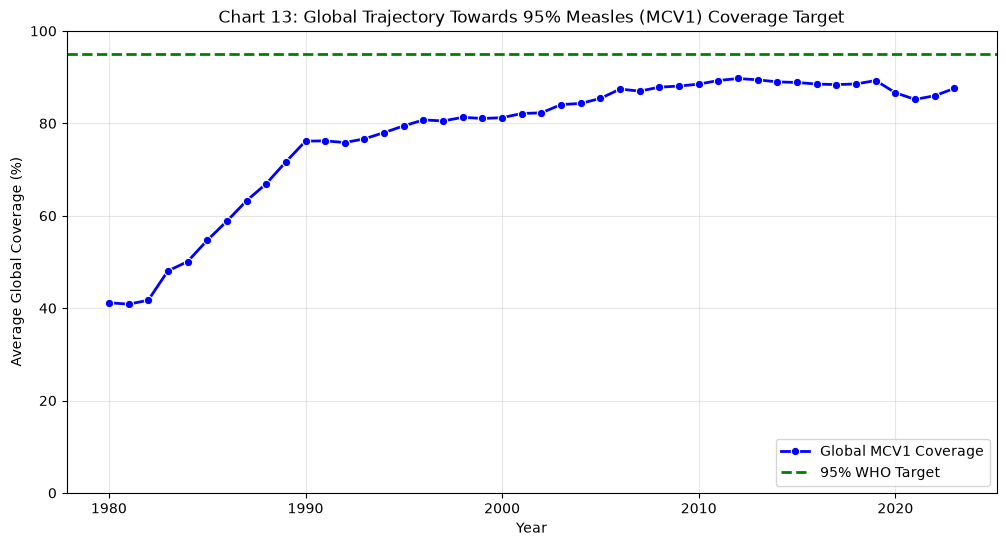

In [334]:
# Question: Track global progress toward achieving a target of 95% vaccination coverage for measles by 2030.
mcv1_cov = coverage_clean[coverage_clean['antigen'] == 'MCV1']
global_mcv1 = mcv1_cov.groupby('year')['coverage'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=global_mcv1, x='year', y='coverage', marker='o', color='blue', linewidth=2, label='Global MCV1 Coverage')
plt.axhline(95, color='green', linestyle='--', linewidth=2, label='95% WHO Target')
plt.title('Chart 13: Global Trajectory Towards 95% Measles (MCV1) Coverage Target')
plt.xlabel('Year')
plt.ylabel('Average Global Coverage (%)')
plt.ylim(0, 100)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## **5. Solution to Business Objective**



#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the extensive Exploratory Data Analysis aligned with our core problem statement, here are the actionable solutions and strategic recommendations:

**1. Reallocating Resources to Low-Coverage Hotspots:**
Our statistical summaries and bar chart analysis identified severe regional disparities. Global health agencies must pivot funding and logistics away from stabilized regions and directly into the West and Central Africa Region (WCARO) and Low-Income Countries (LICs). These areas are currently hovering near a critically low 30% coverage rate, leaving them highly susceptible to outbreaks.

**2. Bridging the Final Gap in Global Targets:**
Line graph trend analysis reveals that while historical vaccination campaigns were incredibly successful (e.g., dropping Measles cases from 2.5 million to under 2 million), current strategies have stagnated. With global MCV1 coverage plateauing at 87.5%, the WHO must abandon "business-as-usual" tactics and adopt targeted, localized outreach programs to break through the plateau and reach the 95% target by 2030.

**3. Mitigating Volatile Outbreak Risks (The 50% Threshold):**
Correlation analysis and scatter plots proved that dropping below 50% coverage acts as a critical failure point, resulting in massive, chaotic outbreaks (such as the 13 extreme Polio outbreak events identified). Policy-makers must establish emergency stockpiles and rapid-response logistics specifically designed for populations where coverage threatens to dip below this 50% herd-immunity floor.

**4. Addressing Supply Chain Disparities:**
Heatmaps and regional timeline distributions (boxplots) highlighted a systemic flaw in the global supply chain: developing regions (like Africa and Southeast Asia) receive new vaccines significantly later than Europe or the Americas. Pharmaceutical companies and NGOs must collaborate to decentralize vaccine manufacturing and establish localized distribution hubs to eliminate these deadly rollout delays.

**Next Steps (Phase 2):**
To make these insights dynamic and accessible to non-technical stakeholders, the cleaned datasets (Dimension and Fact tables) will now be exported to a SQL Database and connected to Power BI to build an interactive, real-time tracking dashboard.

# **Conclusion**

This project successfully engineered a comprehensive end-to-end data pipeline to analyze global vaccination coverage and disease incidence. 

Starting with raw, complex datasets, we performed rigorous data wrangling in Python using Pandas—handling missing values, standardizing identifiers, and reshaping the data to uncover critical patterns. The Exploratory Data Analysis (EDA) revealed a clear and direct correlation: regions with consistently high vaccination coverage experience drastically lower disease incidence. Conversely, we identified that lower-income regions, particularly the African Region, continue to face systemic lags in coverage, rendering them highly vulnerable to preventable outbreaks.

To operationalize these insights, we architected a robust Star Schema database in PostgreSQL (Neon Tech) containing optimized Fact and Dimension tables. This clean, relational data was then seamlessly integrated into Power BI. We built an interactive, dynamic dashboard featuring Geographical Heatmaps, 40-year Historical Trend Lines, Correlation Scatter Plots, and Target KPIs. 

Ultimately, this project proves that data-driven decision-making is essential for public health. By utilizing this automated dashboard, global health organizations can now monitor progress against the 95% global target in real-time, identify geographical vulnerabilities instantly, and strategically deploy life-saving vaccines to the regions that need them most.